In [ ]:
class Ball:
    def __init__(self, start_x, start_y, radius):
        self.r = np.array([start_x, start_y], dtype=float)
        self.v = np.array([0.0, 0.0])
        self.radius = radius
        self.active = True
        self.counted = False
        self.bounces = 0
        self.time_alive = 0.0
        self.time_to_ground = None


    def update(self, pegs, R, e, left_wall, right_wall):
        if not self.active:
            return

        self.time_alive += dt

        self.v[1] -= g * dt
        self.r += self.v * dt

        # Stop at ground
        if self.r[1] <= self.radius:
            self.r[1] = self.radius
            self.v[:] = 0
            self.active = False
            self.time_to_ground = self.time_alive
            return

        # Side walls
        if self.r[0] < left_wall + self.radius:
            self.r[0] = left_wall + self.radius
            self.v[0] *= -e

        if self.r[0] > right_wall - self.radius:
            self.r[0] = right_wall - self.radius
            self.v[0] *= -e

        # Bin divider collisions
        bin_height = spacing

        if self.r[1] <= bin_height + self.radius:
            for edge in bin_edges:
                # Check collision with vertical divider
                if abs(self.r[0] - edge) < self.radius:

                    # Determine which side of wall we are on
                    if self.r[0] < edge:
                        self.r[0] = edge - self.radius
                        self.v[0] *= -e
                    else:
                        self.r[0] = edge + self.radius
                        self.v[0] *= -e

        # Peg collisions
        for peg in pegs:
            if abs(self.r[1] - peg[1]) > spacing:
                continue  # Skip far pegs

            diff = self.r - peg
            dist = np.linalg.norm(diff)

            if dist < R + self.radius:
                normal = diff / dist

                if np.dot(self.v, normal) < 0:
                    self.v = reflect_velocity(self.r, self.v, peg, e)
                    self.bounces += 1

                self.r = peg + normal * (R + self.radius)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from google.colab import files

g = 9.81
dt = 0.05

# Generate pegs
def generate_pegs(rows, cols, spacing):
    pegs = []

    for row in range(rows):
        y = rows * spacing - row * spacing

        # Alternate (first row always odd)
        if row % 2 == 0:
            n_pegs = cols - 1
        else:
            n_pegs = cols

        # Center the row horizontally
        row_width = (n_pegs - 1) * spacing
        x_start = -row_width / 2

        for col in range(n_pegs):
            x = x_start + col * spacing
            pegs.append((x, y))

    return np.array(pegs)


# Reflect off pegs
def reflect_velocity(r, v, centre, e):
    n = r - centre
    n = n / np.linalg.norm(n)

    vn = np.dot(v, n)
    v_normal = vn * n
    v_tangent = v - v_normal

    return v_tangent - e * v_normal

# Animation
def animate(frame):
    global bin_counts

    for i, ball in enumerate(balls):
        ball.update(pegs, R, e, left_wall, right_wall)
        ball_patches[i].center = ball.r

        if not ball.active and not ball.counted:
            bin_width = bin_edges[1] - bin_edges[0]
            bin_index = int((ball.r[0] - bin_edges[0]) // bin_width)
            bin_index = max(0, min(bin_index, len(bin_counts) - 1))

            bin_counts[bin_index] += 1
            ball.counted = True

    if np.sum(bin_counts) >= num_balls:
        ani.event_source.stop()

    return ball_patches

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[ 0.  0.  0.  1.  1.  2.  7.  7.  4.  8.  7. 11.  1.  0.  1.  0.  0.  0.
  0.]


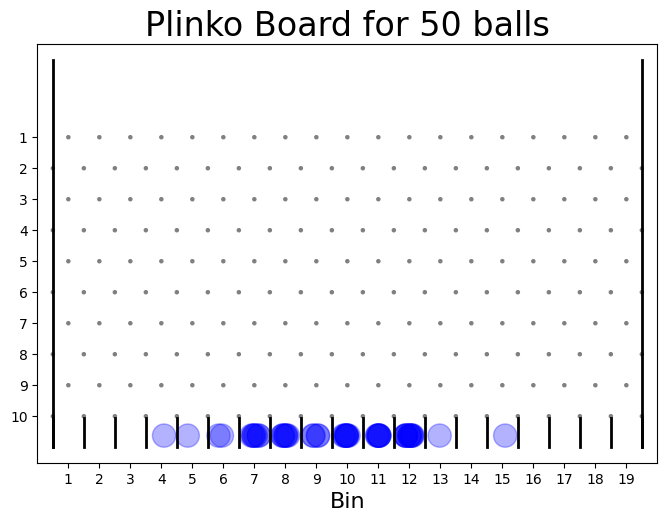

In [ ]:
rows = 10
cols = 20
spacing = 2
ball_radius = 0.75
R = 0.1
d = 0.05
h = 5
e = 0.5
num_balls = 50

pegs = generate_pegs(rows, cols, spacing)
board_width = (cols-1) * spacing
left_wall = -(board_width / 2)
right_wall = board_width / 2
top_y = rows * spacing + h

bin_edges = np.linspace(-((cols-1) * spacing)/2, ((cols-1) * spacing)/2, cols)
bin_counts = np.zeros(cols-1)

# Drop window for balls
balls = [
    Ball(np.random.uniform(-d, d), top_y, ball_radius)
    for _ in range(num_balls)
]

fig, ax = plt.subplots(figsize=(8, 10))

# Draw pegs
for peg in pegs:
    ax.add_patch(plt.Circle((peg[0], peg[1]), R, color='grey'))

# Draw side walls
ax.plot([left_wall, left_wall], [0, top_y], linewidth=2, color='black')
ax.plot([right_wall, right_wall], [0, top_y], linewidth=2, color='black')

# Draw bins
for edge in bin_edges:
    ax.plot([edge, edge], [0, (spacing-R)], linewidth=2, color='black')

# Ball patches
ball_patches = []
for ball in balls:
    patch = plt.Circle(ball.r, ball.radius, color='blue', alpha=0.3)
    ax.add_patch(patch)
    ball_patches.append(patch)

# Set axis limits and labels
ax.set_xlim(left_wall - 1, right_wall + 1)
ax.set_ylim(-1, top_y + 1)
ax.set_aspect('equal', 'box')
ax.set_title(f"Plinko Board for {num_balls} balls", fontsize=24)

# Set x-ticks for bins (1 to 29)
ax.set_xticks(np.arange(-(cols-2), cols, 2))  # This will set the ticks from 0 to 28
ax.set_xticklabels([f"{i+1}" for i in range(cols - 1)])  # Label bins as 1 to 29
plt.xlabel("Bin", fontsize=16)

# Set y-ticks to peg levels
peg_levels = np.arange(rows, 0, -1) * spacing
ax.set_yticks(peg_levels)
ax.set_yticklabels([i for i in range(1, rows + 1)])

ani = FuncAnimation(fig, animate, frames=350, interval=40, cache_frame_data=False, repeat=False)
#display(HTML(ani.to_jshtml()))

file_name = f"plinko {num_balls} balls.mp4"
ani.save(file_name, writer="ffmpeg", fps=30)
files.download(file_name)

print(bin_counts)

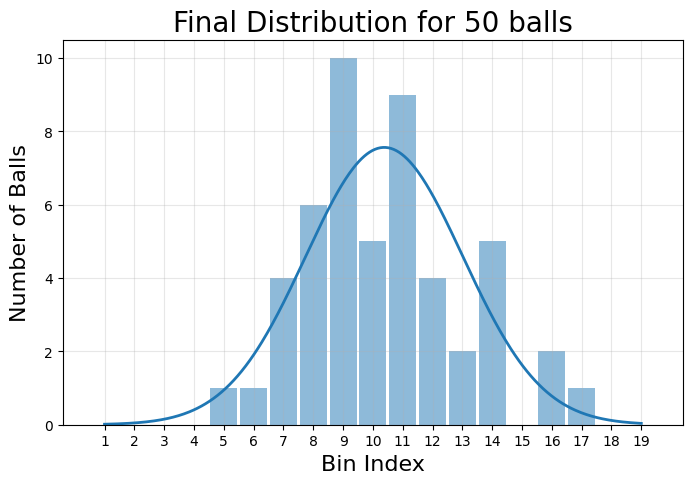

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bins = np.arange(len(bin_counts))+1
plt.bar(bins, bin_counts, width=0.9, alpha=0.5)

expanded_data = np.repeat(bins, bin_counts.astype(int))
mu = np.mean(expanded_data)
sigma = np.std(expanded_data)

x = np.linspace(1, len(bin_counts), 400)
y = norm.pdf(x, mu, sigma) * sum(bin_counts)
plt.plot(x, y, linewidth=2)

plt.xlabel("Bin Index", fontsize='16')
plt.ylabel("Number of Balls", fontsize='16')
plt.title(f"Final Distribution for {num_balls} balls", fontsize=20)
plt.xticks(bins)
plt.grid(True, alpha=0.3)
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.   2.   9.
  32.  41.  82. 109. 141. 155. 129. 108.  89.  51.  33.  11.   3.   2.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
1000.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[  0.   1.   0.   0.   0.   0.   0.   1.   0.   6.   6.  13.  18.  32.
  46.  54.  80. 103.  79. 108. 103.  85.  85.  55.  51.  34.  19.   9.
  10.   2.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
1000.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[ 0.  0.  1.  0.  0.  0.  2.  6.  7. 14. 18. 18. 34. 33. 47. 63. 84. 57.
 85. 88. 65. 76. 70. 60. 47. 38. 22. 22.  9.  7. 13.  9.  0.  2.  2.  1.
  0.  0.  0.]
1000.0


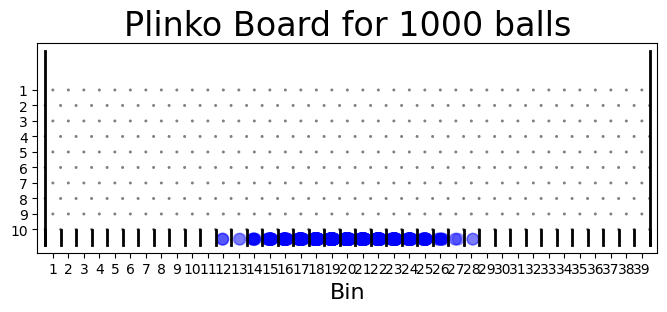

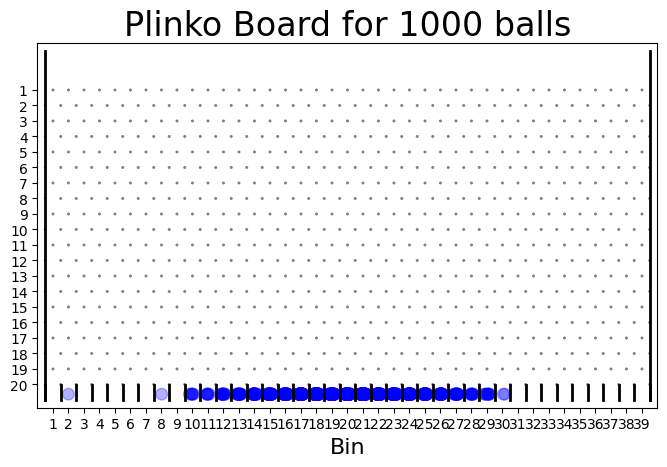

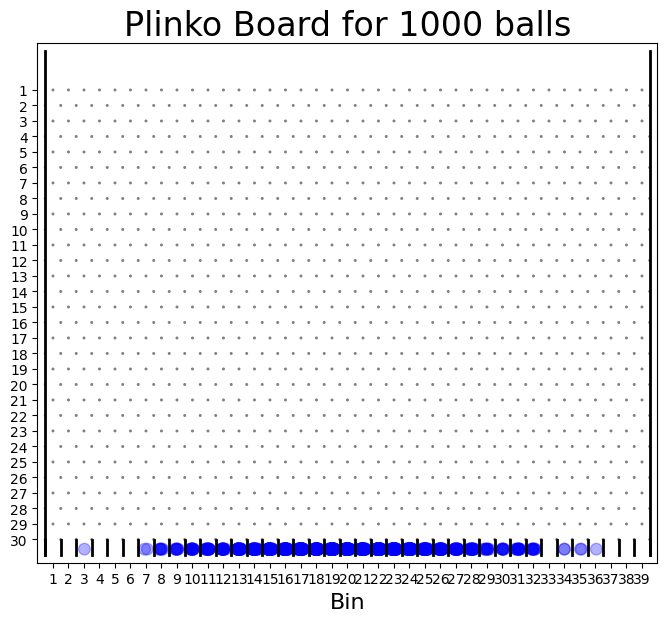

In [ ]:
rows_vals = [10, 20, 30]
cols = 40
spacing = 2
ball_radius = 0.75
R = 0.1
d = 0.05
h = 5
e = 0.5
num_balls = 1000

row_bin_counts = []

for rows in rows_vals:
    pegs = generate_pegs(rows, cols, spacing)
    board_width = (cols-1) * spacing
    left_wall = -(board_width / 2)
    right_wall = board_width / 2
    top_y = rows * spacing + h

    bin_edges = np.linspace(-((cols-1) * spacing)/2, ((cols-1) * spacing)/2, cols)
    bin_counts = np.zeros(cols-1)

    # Drop window for balls
    balls = [
        Ball(np.random.uniform(-d, d), top_y, ball_radius)
        for _ in range(num_balls)
    ]

    fig, ax = plt.subplots(figsize=(8, 10))

    # Draw pegs
    for peg in pegs:
        ax.add_patch(plt.Circle((peg[0], peg[1]), R, color='grey'))

    # Draw side walls
    ax.plot([left_wall, left_wall], [0, top_y], linewidth=2, color='black')
    ax.plot([right_wall, right_wall], [0, top_y], linewidth=2, color='black')

    # Draw bins
    for edge in bin_edges:
        ax.plot([edge, edge], [0, (spacing-R)], linewidth=2, color='black')

    # Ball patches
    ball_patches = []
    for ball in balls:
        patch = plt.Circle(ball.r, ball.radius, color='blue', alpha=0.3)
        ax.add_patch(patch)
        ball_patches.append(patch)

    # Set axis limits and labels
    ax.set_xlim(left_wall - 1, right_wall + 1)
    ax.set_ylim(-1, top_y + 1)
    ax.set_aspect('equal', 'box')
    ax.set_title(f"Plinko Board for {num_balls} balls", fontsize='24')

    # Set x-ticks for bins (1 to 29)
    ax.set_xticks(np.arange(-(cols-2), cols, 2))
    ax.set_xticklabels([f"{i+1}" for i in range(cols - 1)])  # Label bins as 1 to 29
    plt.xlabel("Bin", fontsize='16')

    # Set y-ticks to peg levels
    peg_levels = np.arange(rows, 0, -1) * spacing
    ax.set_yticks(peg_levels)
    ax.set_yticklabels([i for i in range(1, rows + 1)])

    ani = FuncAnimation(fig, animate, frames=36*rows, interval=40, cache_frame_data=False, repeat=False)
    # display(HTML(ani.to_jshtml()))

    file_name = f"plinko {num_balls} balls {rows} rows.mp4"
    ani.save(file_name, writer="ffmpeg", fps=20)
    files.download(file_name)

    print(bin_counts)
    print(sum(bin_counts))
    row_bin_counts.append(bin_counts)

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bins = np.arange(len(row_bin_counts[0]))+1
colors = ['blue', 'orange', 'darkgreen']
labels = ['Rows = 10', 'Rows = 20', 'Rows = 30']

# Loop over the bin counts for each row configuration
for i, bin_counts in enumerate(row_bin_counts):
    plt.bar(bins, bin_counts, width=0.9, alpha=0.6-0.1*i, label=labels[i], color=colors[i])
    plt.bar(bins, bin_counts, width=0.9, color=(0,0,0,0), edgecolor='black')

    expanded_data = np.repeat(bins, bin_counts.astype(int))
    mu = np.mean(expanded_data)
    sigma = np.std(expanded_data)

    x = np.linspace(1, len(bin_counts), 400)
    y = norm.pdf(x, mu, sigma) * sum(bin_counts)
    plt.plot(x, y, linewidth=2, color=colors[i])

    # # Plot each histogram with slight transparency
    # plt.bar(bins + i * 0.2, bin_counts, width=0.2, alpha=0.6, label=labels[i], color=colors[i])

    # # Fit a normal distribution to the data
    # expanded_data = np.repeat(bins, bin_counts.astype(int))
    # mu = np.mean(expanded_data)
    # sigma = np.std(expanded_data)

    # # Overlay normal distribution fit
    # x = np.linspace(0, len(bin_counts) - 1, 400)
    # y = norm.pdf(x, mu, sigma) * sum(bin_counts)
    # plt.plot(x + i * 0.2, y, linewidth=2, color=colors[i])

plt.xlabel("Bin Index", fontsize='16')
plt.ylabel("Number of Balls", fontsize='16')
plt.title(f"Final Distribution for {num_balls} balls", fontsize='20')
plt.xticks(bins, bins, fontsize='8')
plt.grid(True, alpha=0.4)
plt.legend(frameon=True, fontsize='16')
plt.show()

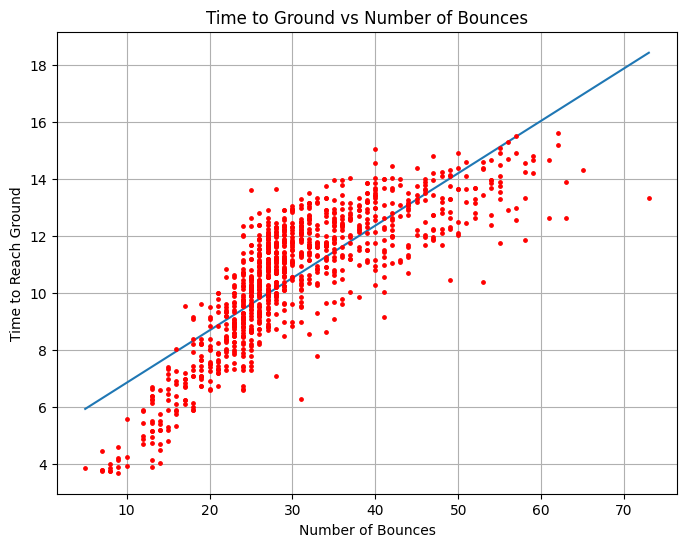

In [ ]:
best_fit_degree = 1

bounce_counts = np.array([ball.bounces for ball in balls])
times = np.array([ball.time_to_ground for ball in balls])

coeffs = np.polyfit(bounce_counts, times, best_fit_degree)
poly = np.poly1d(coeffs)

x_line = np.linspace(min(bounce_counts), max(bounce_counts), 100)
y_line = poly(x_line)

plt.figure(figsize=(8,6))
plt.scatter(bounce_counts, times, s=6, color='red', zorder=5)
plt.plot(x_line, y_line)

plt.xlabel("Number of Bounces")
plt.ylabel("Time to Reach Ground")
plt.title("Time to Ground vs Number of Bounces")

plt.grid(True)
plt.show()